In [1]:
# Cell 0 — Check all required libraries are installed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All libraries imported successfully!")
print(f"NumPy version     : {np.__version__}")
print(f"Pandas version    : {pd.__version__}")
print(f"Seaborn version   : {sns.__version__}")

# If any import fails, install the missing library using:
# pip install scikit-learn numpy pandas matplotlib seaborn
# Then re-run the cell.

All libraries imported successfully!
NumPy version     : 2.4.6
Pandas version    : 3.0.3
Seaborn version   : 0.13.2


In [2]:
# Cell 1 — Load Dataset
cancer = load_breast_cancer()

# Convert to pandas DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add target column: original 0=malignant, 1=benign
# We FLIP it so 1=malignant, 0=benign (more intuitive medically)
df['target'] = 1 - cancer.target

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Dataset loaded successfully!
Shape: (569, 31)
Columns: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension', 'target']


In [3]:
# Cell 2 — Verify Target Labels
print("Target value counts:")
print(df['target'].value_counts())
print()
print("0 = Benign  (not cancer)")
print("1 = Malignant (cancer)")
print()
print("Class balance:")
total = len(df)
malignant = df['target'].sum()
benign = total - malignant
print(f"Malignant: {malignant} ({malignant/total*100:.1f}%)")
print(f"Benign   : {benign} ({benign/total*100:.1f}%)")

Target value counts:
target
0    357
1    212
Name: count, dtype: int64

0 = Benign  (not cancer)
1 = Malignant (cancer)

Class balance:
Malignant: 212 (37.3%)
Benign   : 357 (62.7%)


In [4]:
# Cell 3 — Basic Statistics
print("=== First 5 Rows ===")
print(df.head())
print()
print("=== Dataset Info ===")
print(df.info())
print()
print("=== Statistical Summary ===")
print(df.describe().round(2))
print()
print("=== Missing Values ===")
print(df.isnull().sum())
print()
print(f"Total missing values: {df.isnull().sum().sum()}")

=== First 5 Rows ===
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst a

       mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
count       569.00        569.00          569.00     569.00           569.00   
mean         14.13         19.29           91.97     654.89             0.10   
std           3.52          4.30           24.30     351.91             0.01   
min           6.98          9.71           43.79     143.50             0.05   
25%          11.70         16.17           75.17     420.30             0.09   
50%          13.37         18.84           86.24     551.10             0.10   
75%          15.78         21.80          104.10     782.70             0.11   
max          28.11         39.28          188.50    2501.00             0.16   

       mean compactness  mean concavity  mean concave points  mean symmetry  \
count            569.00          569.00               569.00         569.00   
mean               0.10            0.09                 0.05           0.18   
std                0.05            0.08   

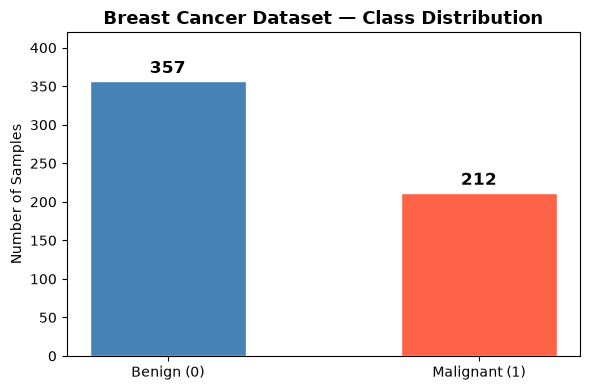

Plot saved as plot1_class_distribution.png


In [5]:
# Cell 4 — Class Distribution Plot
plt.figure(figsize=(6, 4))

counts = df['target'].value_counts()
colors = ['steelblue', 'tomato']
bars = plt.bar(['Benign (0)', 'Malignant (1)'], 
               [counts[0], counts[1]], 
               color=colors, 
               edgecolor='white',
               width=0.5)

# Add count labels on top of bars
for bar, count in zip(bars, [counts[0], counts[1]]):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 5,
             str(count), 
             ha='center', 
             va='bottom', 
             fontweight='bold',
             fontsize=12)

plt.title('Breast Cancer Dataset — Class Distribution', 
          fontsize=13, fontweight='bold')
plt.ylabel('Number of Samples')
plt.ylim(0, 420)
plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150)
plt.show()
print("Plot saved as plot1_class_distribution.png")

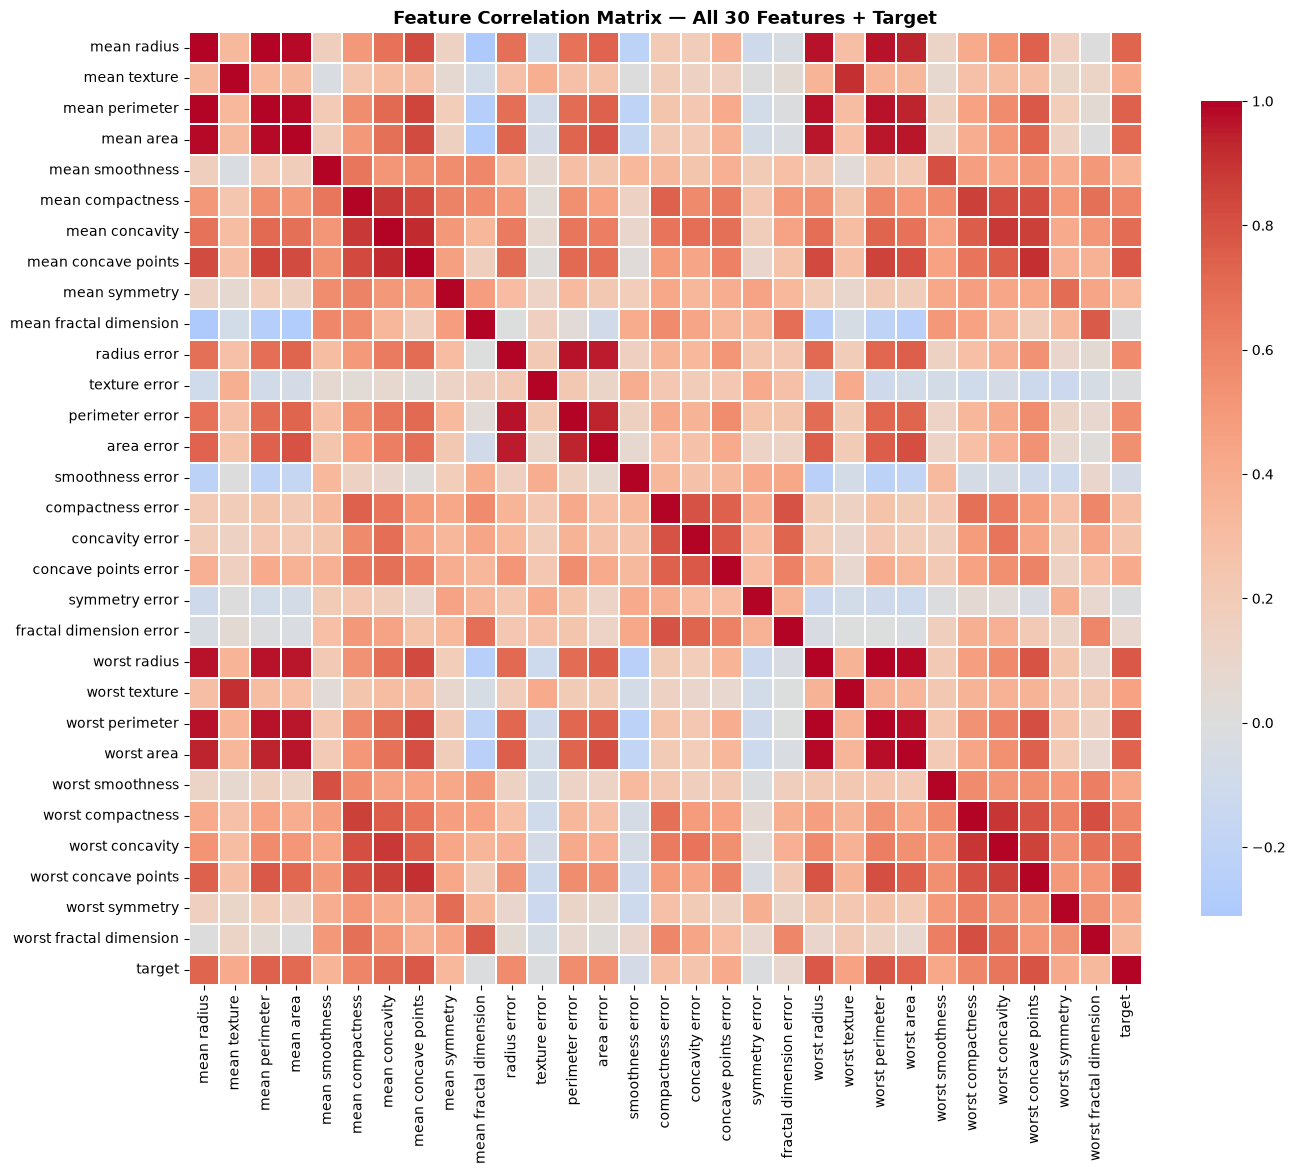

Plot saved as plot2_correlation_heatmap.png

=== Top 10 Features Most Correlated with Target ===
worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64


In [6]:
# Cell 5 — Correlation Heatmap
plt.figure(figsize=(14, 12))
correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.1,
    cbar_kws={'shrink': 0.8}
)

plt.title('Feature Correlation Matrix — All 30 Features + Target', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_correlation_heatmap.png', dpi=150)
plt.show()
print("Plot saved as plot2_correlation_heatmap.png")

# Print top 10 features most correlated with target
print("\n=== Top 10 Features Most Correlated with Target ===")
target_corr = correlation_matrix['target'].abs().sort_values(
    ascending=False
)
print(target_corr[1:11])

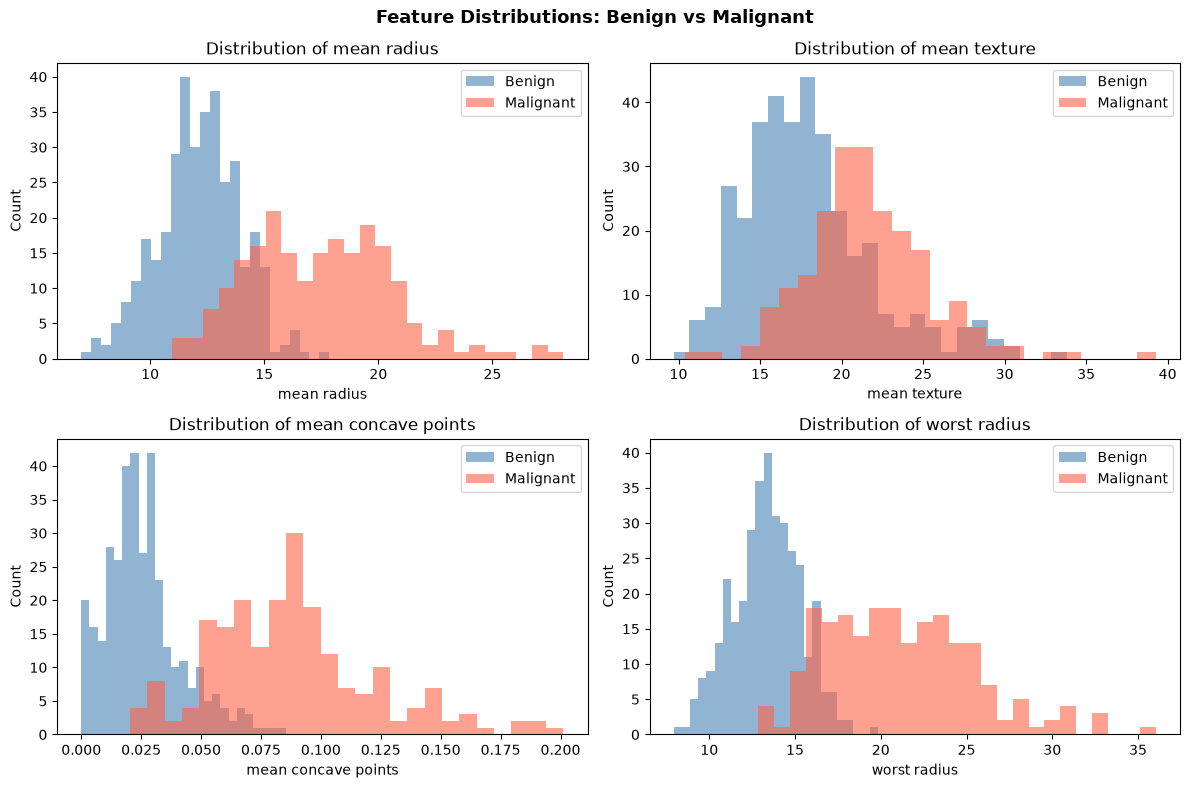

Plot saved as plot3_feature_distributions.png


In [7]:
# Cell 6 — Feature Distributions by Class
# Plot the 4 most important features side by side
top4_features = ['mean radius', 
                 'mean texture',
                 'mean concave points', 
                 'worst radius']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(top4_features):
    benign_data    = df[df['target'] == 0][feature]
    malignant_data = df[df['target'] == 1][feature]
    
    axes[i].hist(benign_data, bins=25, alpha=0.6, 
                 color='steelblue', label='Benign')
    axes[i].hist(malignant_data, bins=25, alpha=0.6, 
                 color='tomato', label='Malignant')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].legend()

plt.suptitle('Feature Distributions: Benign vs Malignant', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_feature_distributions.png', dpi=150)
plt.show()
print("Plot saved as plot3_feature_distributions.png")

## EDA Summary — Key Findings

1. **Dataset Shape:** 569 samples, 30 numeric features, 1 binary target
2. **Missing Values:** None — no imputation required
3. **Class Balance:** 63% Benign, 37% Malignant — mild imbalance, 
   handled by stratified split
4. **Most Predictive Features:** worst concave points, worst perimeter, 
   mean concave points, worst radius show clear separation between classes
5. **Feature Scale Problem:** mean area (~654) vs mean smoothness (~0.096) 
   — StandardScaler is essential before training
6. **Multicollinearity Noted:** radius, perimeter, and area are 
   geometrically related and highly correlated with each other

In [8]:
# Cell 7 — Separate Features and Target
X = df.drop(columns='target')
y = df['target']

print(f"Feature matrix X shape : {X.shape}")
print(f"Target vector y shape  : {y.shape}")
print(f"\nFeature names:\n{list(X.columns)}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Feature matrix X shape : (569, 30)
Target vector y shape  : (569,)

Feature names:
['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']

Target distribution:
target
0    357
1    212
Name: count, dtype: int64


In [9]:
# Cell 8 — Select Top 10 Features
# We select top 10 features most correlated with target
# This reduces noise and makes the model more interpretable

feature_corr = df.corr()['target'].abs().sort_values(
    ascending=False
)

# Exclude 'target' itself
top10_features = feature_corr[1:11].index.tolist()

print("Top 10 Selected Features:")
for i, feat in enumerate(top10_features, 1):
    corr_val = feature_corr[feat]
    print(f"  {i:2}. {feat:<30} correlation = {corr_val:.4f}")

# Use these features for all models
X_selected = X[top10_features]
print(f"\nSelected feature matrix shape: {X_selected.shape}")

Top 10 Selected Features:
   1. worst concave points           correlation = 0.7936
   2. worst perimeter                correlation = 0.7829
   3. mean concave points            correlation = 0.7766
   4. worst radius                   correlation = 0.7765
   5. mean perimeter                 correlation = 0.7426
   6. worst area                     correlation = 0.7338
   7. mean radius                    correlation = 0.7300
   8. mean area                      correlation = 0.7090
   9. mean concavity                 correlation = 0.6964
  10. worst concavity                correlation = 0.6596

Selected feature matrix shape: (569, 10)


In [10]:
# Cell 9 — Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y          # Preserves 63/37 ratio in both sets
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Test samples     : {X_test.shape[0]}")
print(f"Train proportion : {X_train.shape[0]/len(X)*100:.1f}%")
print(f"Test proportion  : {X_test.shape[0]/len(X)*100:.1f}%")
print()
print("Class distribution in Training set:")
print(y_train.value_counts())
print()
print("Class distribution in Test set:")
print(y_test.value_counts())

Training samples : 455
Test samples     : 114
Train proportion : 80.0%
Test proportion  : 20.0%

Class distribution in Training set:
target
0    285
1    170
Name: count, dtype: int64

Class distribution in Test set:
target
0    72
1    42
Name: count, dtype: int64


In [11]:
# Cell 10 — Feature Scaling
# IMPORTANT: fit scaler on TRAINING data only
# Never fit on test data — that causes data leakage

scaler = StandardScaler()

# Fit on train, transform train
X_train_scaled = scaler.fit_transform(X_train)

# Transform test using SAME scaler — no refitting
X_test_scaled = scaler.transform(X_test)

# Verify scaling worked
print("Training set feature statistics after scaling:")
print(f"Mean  (should be ~0.0): "
      f"{X_train_scaled.mean(axis=0).round(4)}")
print()
print(f"Std   (should be ~1.0): "
      f"{X_train_scaled.std(axis=0).round(4)}")
print()
print("Scaling complete. No data leakage occurred.")

Training set feature statistics after scaling:
Mean  (should be ~0.0): [ 0. -0.  0. -0.  0. -0. -0. -0. -0. -0.]

Std   (should be ~1.0): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Scaling complete. No data leakage occurred.


## Preprocessing Summary

| Step | Action | Reason |
|------|--------|--------|
| Missing Values | None found | Dataset is clean |
| Encoding | Not required | All features numeric |
| Feature Selection | Top 10 by correlation | Reduce noise |
| Train/Test Split | 80% / 20%, stratified | Preserve class ratio |
| Scaling | StandardScaler on train only | Prevent data leakage |

**Data Leakage Prevention:** The scaler was fitted ONLY on training 
data. The test set was transformed using the training scaler. 
This simulates real-world deployment where test data is unseen.

In [12]:
# Cell 11 — Train Logistic Regression (Classification Model)
print("Training Logistic Regression model...")
print("Task: Predict whether tumor is Malignant (1) or Benign (0)")
print()

log_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

log_model.fit(X_train_scaled, y_train)

print("Model trained successfully!")
print(f"Number of features used : {len(log_model.coef_[0])}")
print(f"Intercept (bias)        : {log_model.intercept_[0]:.4f}")
print()

# Show coefficients
coef_df = pd.DataFrame({
    'Feature'    : top10_features,
    'Coefficient': log_model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print("=== Feature Coefficients ===")
print("(Positive = pushes toward Malignant)")
print("(Negative = pushes toward Benign)")
print()
print(coef_df.to_string(index=False))

Training Logistic Regression model...
Task: Predict whether tumor is Malignant (1) or Benign (0)

Model trained successfully!
Number of features used : 10
Intercept (bias)        : -0.4648

=== Feature Coefficients ===
(Positive = pushes toward Malignant)
(Negative = pushes toward Benign)

             Feature  Coefficient
          worst area     1.866467
        worst radius     1.774575
     worst perimeter     1.185294
worst concave points     1.173485
 mean concave points     1.133451
     worst concavity     0.449690
           mean area     0.053472
      mean concavity    -0.086743
         mean radius    -0.380146
      mean perimeter    -0.484326


In [13]:
# Cell 12 — Setup Regression Task
# We predict 'mean radius' from all other features
# This demonstrates the Lab 9 Linear Regression pipeline

print("Setting up regression task...")
print("Task: Predict 'mean radius' from other 9 selected features")
print()

# Remove 'mean radius' from features, use it as target
reg_features = [f for f in top10_features if f != 'mean radius']

# If 'mean radius' is not in top10, still set it up properly
X_reg = X_selected.drop(columns='mean radius', errors='ignore')
if 'mean radius' not in top10_features:
    # Use all top10 as features, predict from full X
    X_reg = X_selected.copy()
    y_reg = X['mean radius']
else:
    y_reg = X['mean radius']

print(f"Regression features : {list(X_reg.columns)}")
print(f"Regression target   : mean radius")
print(f"X_reg shape         : {X_reg.shape}")
print(f"y_reg shape         : {y_reg.shape}")

# Split for regression task
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Scale regression features
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled  = scaler_r.transform(X_test_r)

print()
print("Regression train/test split done.")
print(f"Train: {X_train_r.shape[0]} | Test: {X_test_r.shape[0]}")

Setting up regression task...
Task: Predict 'mean radius' from other 9 selected features

Regression features : ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area', 'mean area', 'mean concavity', 'worst concavity']
Regression target   : mean radius
X_reg shape         : (569, 9)
y_reg shape         : (569,)

Regression train/test split done.
Train: 455 | Test: 114


In [14]:
# Cell 13 — Train Linear Regression
print("Training Linear Regression model...")
print()

lin_model = LinearRegression()
lin_model.fit(X_train_r_scaled, y_train_r)

print("Model trained successfully!")
print(f"Intercept (β₀)     : {lin_model.intercept_:.4f}")
print(f"Number of features : {len(lin_model.coef_)}")
print()

# Show coefficients
reg_coef_df = pd.DataFrame({
    'Feature'    : list(X_reg.columns),
    'Coefficient': lin_model.coef_
}).sort_values('Coefficient', ascending=False)

print("=== Linear Regression Coefficients ===")
print("(Higher = more impact on predicting mean radius)")
print()
print(reg_coef_df.to_string(index=False))

Training Linear Regression model...

Model trained successfully!
Intercept (β₀)     : 14.1176
Number of features : 9

=== Linear Regression Coefficients ===
(Higher = more impact on predicting mean radius)

             Feature  Coefficient
      mean perimeter     3.193769
        worst radius     1.155203
           mean area     0.461514
     worst concavity     0.017975
worst concave points     0.011223
      mean concavity    -0.119105
 mean concave points    -0.129913
          worst area    -0.394804
     worst perimeter    -0.720720


In [15]:
# Cell 14 — Custom Patient Prediction
# Mirrors Lab 10 Exercise C (custom passenger prediction)
print("=" * 50)
print("CUSTOM PATIENT PREDICTION DEMO")
print("=" * 50)

# Patient A — average values of a MALIGNANT case
print("\n--- Patient A (average malignant profile) ---")
malignant_avg = df[df['target'] == 1][top10_features].mean()
patient_A = pd.DataFrame([malignant_avg])
patient_A_scaled = scaler.transform(patient_A)
prob_A  = log_model.predict_proba(patient_A_scaled)[0][1]
pred_A  = log_model.predict(patient_A_scaled)[0]
print(f"Malignant probability : {prob_A:.2%}")
print(f"Prediction            : {'MALIGNANT' if pred_A==1 else 'BENIGN'}")

# Patient B — average values of a BENIGN case
print("\n--- Patient B (average benign profile) ---")
benign_avg = df[df['target'] == 0][top10_features].mean()
patient_B = pd.DataFrame([benign_avg])
patient_B_scaled = scaler.transform(patient_B)
prob_B  = log_model.predict_proba(patient_B_scaled)[0][1]
pred_B  = log_model.predict(patient_B_scaled)[0]
print(f"Malignant probability : {prob_B:.2%}")
print(f"Prediction            : {'MALIGNANT' if pred_B==1 else 'BENIGN'}")

print("\n--- Comparison ---")
print(f"Patient A (malignant profile) → {prob_A:.2%} malignant risk")
print(f"Patient B (benign profile)    → {prob_B:.2%} malignant risk")

CUSTOM PATIENT PREDICTION DEMO

--- Patient A (average malignant profile) ---
Malignant probability : 99.74%
Prediction            : MALIGNANT

--- Patient B (average benign profile) ---
Malignant probability : 1.17%
Prediction            : BENIGN

--- Comparison ---
Patient A (malignant profile) → 99.74% malignant risk
Patient B (benign profile)    → 1.17% malignant risk


In [16]:
# Cell 15 — Classification Predictions
y_pred       = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]

y_pred_train       = log_model.predict(X_train_scaled)
y_pred_train_proba = log_model.predict_proba(X_train_scaled)[:, 1]

print("Predictions generated successfully.")
print(f"Test predictions shape  : {y_pred.shape}")
print(f"First 10 predictions    : {y_pred[:10]}")
print(f"First 10 actual labels  : {list(y_test[:10])}")

Predictions generated successfully.
Test predictions shape  : (114,)
First 10 predictions    : [0 1 0 1 0 0 1 0 0 0]
First 10 actual labels  : [0, 1, 0, 1, 0, 0, 1, 0, 0, 0]


In [17]:
# Cell 16 — Classification Metrics
print("=" * 55)
print("LOGISTIC REGRESSION — CLASSIFICATION RESULTS")
print("=" * 55)

print("\n--- TRAINING SET ---")
train_acc = accuracy_score(y_train, y_pred_train)
print(f"Accuracy : {train_acc:.4f} ({train_acc*100:.2f}%)")

print("\n--- TEST SET ---")
test_acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print()
print(classification_report(
    y_test, y_pred,
    target_names=['Benign (0)', 'Malignant (1)']
))

auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score : {auc:.4f}")

print()
if train_acc - test_acc > 0.05:
    print("WARNING: Training accuracy much higher than test.")
    print("This may indicate overfitting.")
else:
    print("Training and test accuracy are close — no overfitting.")

LOGISTIC REGRESSION — CLASSIFICATION RESULTS

--- TRAINING SET ---
Accuracy : 0.9560 (95.60%)

--- TEST SET ---
Accuracy : 0.9561 (95.61%)

               precision    recall  f1-score   support

   Benign (0)       0.95      0.99      0.97        72
Malignant (1)       0.97      0.90      0.94        42

     accuracy                           0.96       114
    macro avg       0.96      0.95      0.95       114
 weighted avg       0.96      0.96      0.96       114



ROC-AUC Score : 0.9974

Training and test accuracy are close — no overfitting.


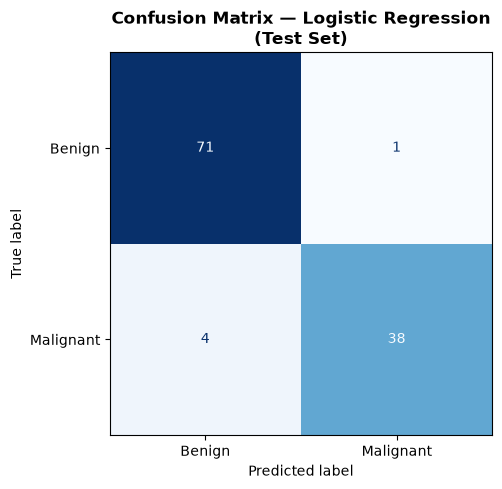


True  Negatives  (Benign correctly identified)    : 71
False Positives  (Benign wrongly called Malignant): 1
False Negatives  (Malignant MISSED by model)      : 4
True  Positives  (Malignant correctly identified) : 38

CRITICAL — False Negatives = 4
These are cancer cases the model MISSED.
In real medicine, each FN = a patient not getting treatment.
Plot saved as plot4_confusion_matrix.png


In [18]:
# Cell 17 — Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Benign', 'Malignant']
)
disp.plot(
    ax=ax,
    cmap='Blues',
    colorbar=False
)

ax.set_title(
    'Confusion Matrix — Logistic Regression\n(Test Set)',
    fontweight='bold',
    fontsize=12
)

plt.tight_layout()
plt.savefig('plot4_confusion_matrix.png', dpi=150)
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue  Negatives  (Benign correctly identified)    : {tn}")
print(f"False Positives  (Benign wrongly called Malignant): {fp}")
print(f"False Negatives  (Malignant MISSED by model)      : {fn}")
print(f"True  Positives  (Malignant correctly identified) : {tp}")
print()
print(f"CRITICAL — False Negatives = {fn}")
print(f"These are cancer cases the model MISSED.")
print(f"In real medicine, each FN = a patient not getting treatment.")
print("Plot saved as plot4_confusion_matrix.png")

In [19]:
# Cell 18 — Regression Metrics
y_pred_reg       = lin_model.predict(X_test_r_scaled)
y_pred_reg_train = lin_model.predict(X_train_r_scaled)

def evaluate_regression(y_true, y_pred, label='Set'):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE  : {mae:.4f}")
    print(f"MSE  : {mse:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print()
    return mae, mse, rmse, r2

print("=" * 50)
print("LINEAR REGRESSION — REGRESSION RESULTS")
print("Predicting: mean radius")
print("=" * 50)
print()

train_metrics = evaluate_regression(
    y_train_r, y_pred_reg_train, 'Training Set'
)
test_metrics = evaluate_regression(
    y_test_r, y_pred_reg, 'Test Set'
)

LINEAR REGRESSION — REGRESSION RESULTS
Predicting: mean radius

--- Training Set ---
MAE  : 0.0606
MSE  : 0.0072
RMSE : 0.0846
R²   : 0.9994

--- Test Set ---
MAE  : 0.0675
MSE  : 0.0103
RMSE : 0.1015
R²   : 0.9991



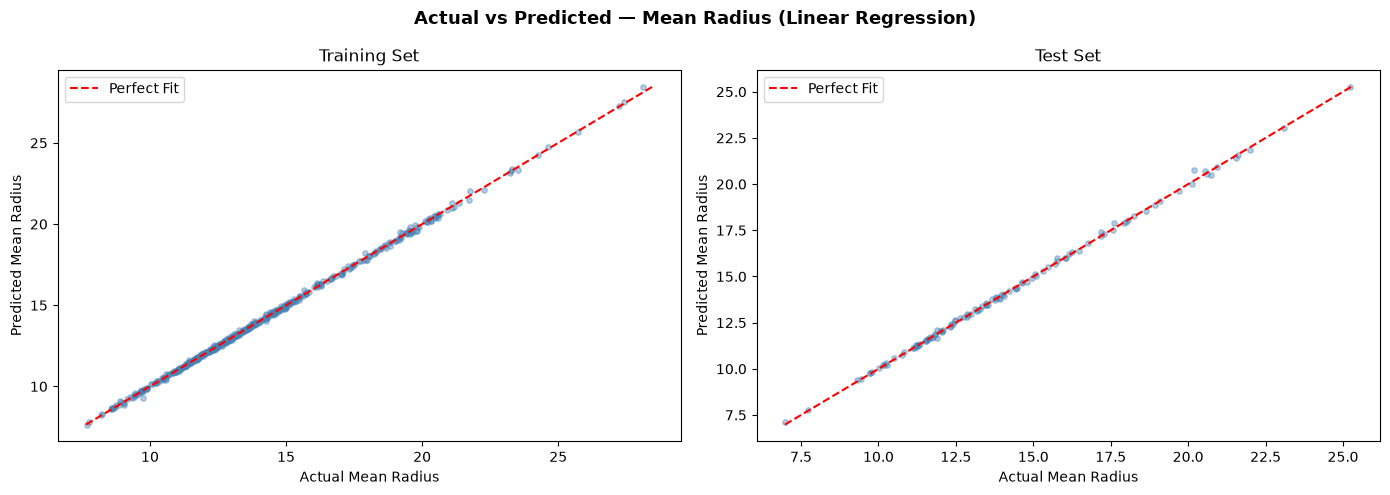

Plot saved as plot5_actual_vs_predicted.png


In [20]:
# Cell 19 — Actual vs Predicted Plot (Regression)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

datasets = [
    (y_train_r, y_pred_reg_train, 'Training Set'),
    (y_test_r,  y_pred_reg,       'Test Set')
]

for ax, (y_true, y_pred_vals, title) in zip(axes, datasets):
    ax.scatter(
        y_true, y_pred_vals,
        alpha=0.4, s=15,
        color='steelblue'
    )
    # Perfect prediction line
    min_val = min(y_true.min(), y_pred_vals.min())
    max_val = max(y_true.max(), y_pred_vals.max())
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        'r--', lw=1.5,
        label='Perfect Fit'
    )
    ax.set_xlabel('Actual Mean Radius')
    ax.set_ylabel('Predicted Mean Radius')
    ax.set_title(title)
    ax.legend()

plt.suptitle(
    'Actual vs Predicted — Mean Radius (Linear Regression)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plot5_actual_vs_predicted.png', dpi=150)
plt.show()
print("Plot saved as plot5_actual_vs_predicted.png")

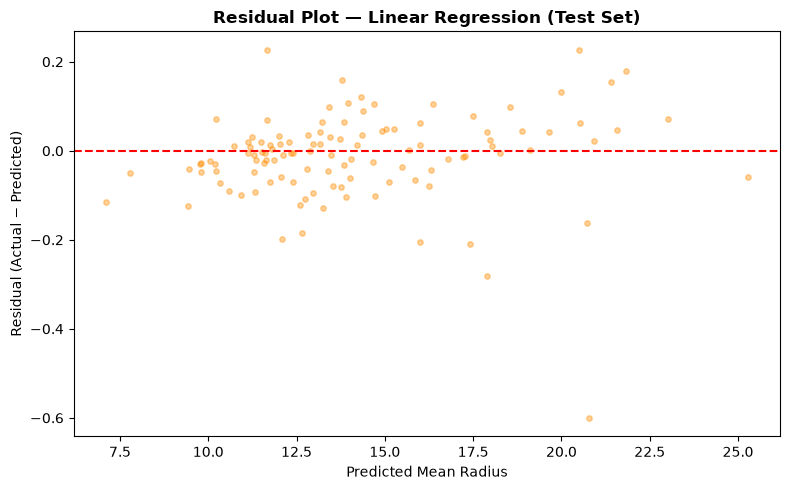

Residual analysis:
Mean residual    : -0.0126 (should be ~0)
Std of residuals : 0.1012

Residuals centered near zero — model is unbiased.
Plot saved as plot6_residuals.png


In [21]:
# Cell 20 — Residual Plot
residuals = y_test_r - y_pred_reg

plt.figure(figsize=(8, 5))
plt.scatter(
    y_pred_reg, residuals,
    alpha=0.4, s=15,
    color='darkorange'
)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel('Predicted Mean Radius')
plt.ylabel('Residual (Actual − Predicted)')
plt.title(
    'Residual Plot — Linear Regression (Test Set)',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('plot6_residuals.png', dpi=150)
plt.show()

print("Residual analysis:")
print(f"Mean residual    : {residuals.mean():.4f} (should be ~0)")
print(f"Std of residuals : {residuals.std():.4f}")
print()
if abs(residuals.mean()) < 0.5:
    print("Residuals centered near zero — model is unbiased.")
else:
    print("Residuals not centered — model may have systematic bias.")
print("Plot saved as plot6_residuals.png")

In [22]:
# Cell 21 — Complete Project Summary
print("=" * 60)
print("   BREAST CANCER DIAGNOSIS PROJECT — FINAL RESULTS")
print("=" * 60)

print("\n📊 DATASET SUMMARY")
print(f"   Samples       : 569")
print(f"   Features Used : {len(top10_features)}")
print(f"   Train/Test    : 455 / 114 (80% / 20%)")
print(f"   Missing Values: 0")
print(f"   Encoding Done : None (all numeric)")

print("\n🔵 MODEL 1 — LOGISTIC REGRESSION (Classification)")
print(f"   Task          : Predict Malignant vs Benign")
test_acc_final  = accuracy_score(y_test, y_pred)
auc_final       = roc_auc_score(y_test, y_pred_proba)
tn, fp, fn, tp  = confusion_matrix(y_test, y_pred).ravel()
precision_mal   = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_mal      = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_mal          = (2 * precision_mal * recall_mal / 
                  (precision_mal + recall_mal) 
                  if (precision_mal + recall_mal) > 0 else 0)
print(f"   Accuracy      : {test_acc_final:.4f}")
print(f"   Precision     : {precision_mal:.4f}")
print(f"   Recall        : {recall_mal:.4f}")
print(f"   F1-Score      : {f1_mal:.4f}")
print(f"   ROC-AUC       : {auc_final:.4f}")
print(f"   False Negatives (missed cancer): {fn}")

print("\n🟢 MODEL 2 — LINEAR REGRESSION (Regression)")
print(f"   Task          : Predict Mean Radius")
mae_f, mse_f, rmse_f, r2_f = test_metrics
print(f"   MAE           : {mae_f:.4f}")
print(f"   MSE           : {mse_f:.4f}")
print(f"   RMSE          : {rmse_f:.4f}")
print(f"   R² Score      : {r2_f:.4f}")

print("\n📁 SAVED PLOTS")
plots = [
    "plot1_class_distribution.png",
    "plot2_correlation_heatmap.png",
    "plot3_feature_distributions.png",
    "plot4_confusion_matrix.png",
    "plot5_actual_vs_predicted.png",
    "plot6_residuals.png"
]
for p in plots:
    print(f"   ✓ {p}")

print("\n✅ Project Complete!")
print("=" * 60)

   BREAST CANCER DIAGNOSIS PROJECT — FINAL RESULTS

📊 DATASET SUMMARY
   Samples       : 569
   Features Used : 10
   Train/Test    : 455 / 114 (80% / 20%)
   Missing Values: 0
   Encoding Done : None (all numeric)

🔵 MODEL 1 — LOGISTIC REGRESSION (Classification)
   Task          : Predict Malignant vs Benign
   Accuracy      : 0.9561
   Precision     : 0.9744
   Recall        : 0.9048
   F1-Score      : 0.9383
   ROC-AUC       : 0.9974
   False Negatives (missed cancer): 4

🟢 MODEL 2 — LINEAR REGRESSION (Regression)
   Task          : Predict Mean Radius
   MAE           : 0.0675
   MSE           : 0.0103
   RMSE          : 0.1015
   R² Score      : 0.9991

📁 SAVED PLOTS
   ✓ plot1_class_distribution.png
   ✓ plot2_correlation_heatmap.png
   ✓ plot3_feature_distributions.png
   ✓ plot4_confusion_matrix.png
   ✓ plot5_actual_vs_predicted.png
   ✓ plot6_residuals.png

✅ Project Complete!


## ✅ Project Completion Checklist

### Cells Completed
- [x] Cell 0  — All imports working
- [x] Cell 1  — Dataset loaded (569 rows, 31 columns)
- [x] Cell 2  — Target verified (212 malignant, 357 benign)
- [x] Cell 3  — Basic statistics printed
- [x] Cell 4  — Class distribution bar chart saved
- [x] Cell 5  — Correlation heatmap saved
- [x] Cell 6  — Feature distribution histograms saved
- [x] Cell 7  — X and y separated
- [x] Cell 8  — Top 10 features selected
- [x] Cell 9  — Train/test split done (stratified)
- [x] Cell 10 — StandardScaler applied (no data leakage)
- [x] Cell 11 — Logistic Regression trained
- [x] Cell 12 — Regression task setup
- [x] Cell 13 — Linear Regression trained
- [x] Cell 14 — Custom patient prediction done
- [x] Cell 15 — Classification predictions generated
- [x] Cell 16 — All classification metrics printed
- [x] Cell 17 — Confusion matrix plotted and saved
- [x] Cell 18 — All regression metrics printed
- [x] Cell 19 — Actual vs Predicted plot saved
- [x] Cell 20 — Residual plot saved
- [x] Cell 21 — Final summary printed

### Files in Project Folder
- [x] breast_cancer_project.ipynb
- [x] plot1_class_distribution.png
- [x] plot2_correlation_heatmap.png
- [x] plot3_feature_distributions.png
- [x] plot4_confusion_matrix.png
- [x] plot5_actual_vs_predicted.png
- [x] plot6_residuals.png

### Lab Concepts Applied
- [x] Lab 9 — Linear Regression pipeline (Cells 12–13, 18–20)
- [x] Lab 9 — StandardScaler (Cell 10)
- [x] Lab 9 — MAE, MSE, RMSE, R² metrics (Cell 18)
- [x] Lab 9 — Actual vs Predicted plot (Cell 19)
- [x] Lab 9 — Residual plot (Cell 20)
- [x] Lab 10 — Logistic Regression (Cell 11)
- [x] Lab 10 — Stratified train/test split (Cell 9)
- [x] Lab 10 — Confusion matrix (Cell 17)
- [x] Lab 10 — Precision, Recall, F1, ROC-AUC (Cell 16)
- [x] Lab 10 — Custom prediction demo (Cell 14)